# Jurkat Single-Cell Data Analysis
This notebook analyzes and visualizes the `jurkat.h5` dataset.

In [144]:
import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import numpy as np

sc.settings.verbosity = 3
sc.logging.print_header()
sc.set_figure_params(dpi=80, facecolor='white')

## Load Data
Since the H5 file has a specific structure (X, obs, var), we load it into an `AnnData` object.

In [145]:
# The file is located at the project root, while the notebook is in 'zyt/'
h5_path = '../jurkat.h5'

def load_jurkat_h5(path):
    with h5py.File(path, 'r') as f:
        # Extract X
        X = f['X'][:]
        
        # Extract obs metadata
        obs_dict = {}
        for key in f['obs'].keys():
            if isinstance(f['obs'][key], h5py.Group):
                # Handle categorical data
                categories = f['obs'][key]['categories'][:].astype(str)
                codes = f['obs'][key]['codes'][:]
                obs_dict[key] = pd.Categorical.from_codes(codes, categories)
            else:
                data = f['obs'][key][:]
                if data.dtype == object:
                    data = data.astype(str)
                obs_dict[key] = data
        
        obs = pd.DataFrame(obs_dict)
        
        # Extract var metadata
        var_dict = {}
        for key in f['var'].keys():
            data = f['var'][key][:]
            if data.dtype == object:
                data = data.astype(str)
            var_dict[key] = data
        
        var = pd.DataFrame(var_dict)
        if '_index' in var.columns:
            var.index = var.pop('_index')
            
        adata = ad.AnnData(X=X, obs=obs, var=var)
    return adata

adata = load_jurkat_h5(h5_path)
print(adata)

AnnData object with n_obs × n_vars = 21412 × 18080
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'


/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [146]:
def print_h5_tree(path_or_file, group=None, prefix=""):
    if group is None:
        if isinstance(path_or_file, str):
            with h5py.File(path_or_file, 'r') as f:
                print(f"📦 {path_or_file}")
                print_h5_tree(path_or_file, group=f, prefix="")
        else:
            print(f"📦 {path_or_file.filename}")
            print_h5_tree(path_or_file, group=path_or_file, prefix="")
        return

    items = list(group.items())
    for i, (name, item) in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        if isinstance(item, h5py.Group):
            print(f"{prefix}{connector}📂 {name}/")
            new_prefix = prefix + ("    " if is_last else "│   ")
            print_h5_tree(path_or_file, group=item, prefix=new_prefix)
        else:
            info = f"(shape={item.shape}, dtype={item.dtype})"
            print(f"{prefix}{connector}📄 {name:20} {info}")

print_h5_tree(h5_path)

📦 ../jurkat.h5
├── 📄 X                    (shape=(21412, 18080), dtype=float32)
├── 📂 layers/
├── 📂 obs/
│   ├── 📄 UMI_count            (shape=(21412,), dtype=float32)
│   ├── 📂 batch_var/
│   │   ├── 📄 categories           (shape=(55,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📄 cell_barcode         (shape=(21412,), dtype=object)
│   ├── 📂 cell_type/
│   │   ├── 📄 categories           (shape=(1,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📄 gem_group            (shape=(21412,), dtype=int64)
│   ├── 📂 gene/
│   │   ├── 📄 categories           (shape=(69,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📂 gene_id/
│   │   ├── 📄 categories           (shape=(69,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📂 gene_transcript/
│   │   ├── 📄 categories           (shape=(201,), dtype=object)
│   │   └── 📄 codes               

## Cell Counts per Perturbation
Determine the number of cells available for each perturbation.

Top 20 perturbations by cell count (excluding non-targeting control):
target_gene
TFAM       2555
EIF4B       461
JAZF1       265
HIRA        233
SMARCB1     204
TAF13       200
KDM1A       195
MBTPS1      192
LZTR1       192
METTL3      177
DNMT1       177
SDC1        156
TADA1       144
MED12       143
USF2        141
ARPC2       140
PHF10       136
PTPN1       136
NDUFB4      133
RNF20       131
Name: count, dtype: int64


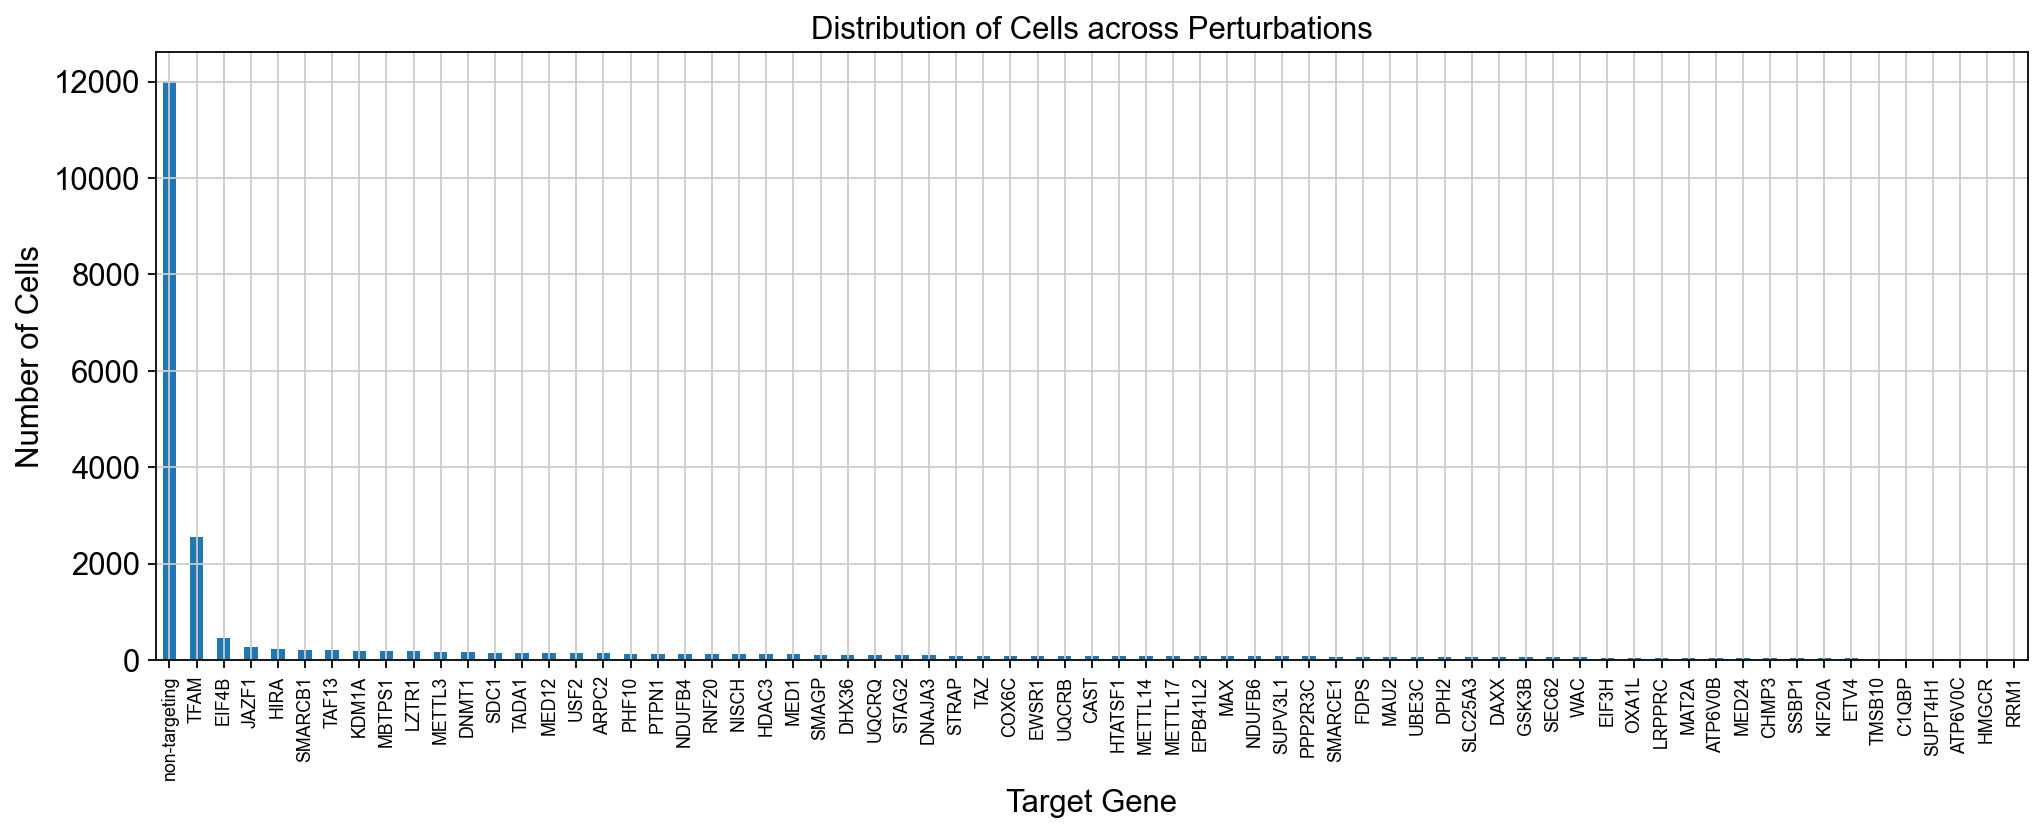


Suggested 20 targets for analysis: ['TFAM', 'EIF4B', 'JAZF1', 'HIRA', 'SMARCB1', 'TAF13', 'KDM1A', 'MBTPS1', 'LZTR1', 'METTL3', 'DNMT1', 'SDC1', 'TADA1', 'MED12', 'USF2', 'ARPC2', 'PHF10', 'PTPN1', 'NDUFB4', 'RNF20']


In [147]:
perturbation_counts = adata.obs['target_gene'].value_counts()
print("Top 20 perturbations by cell count (excluding non-targeting control):")
top_20_targets = perturbation_counts[perturbation_counts.index != 'non-targeting'].head(20)
print(top_20_targets)

plt.figure(figsize=(15, 5))
perturbation_counts.plot(kind='bar')
plt.title('Distribution of Cells across Perturbations')
plt.ylabel('Number of Cells')
plt.xlabel('Target Gene')
plt.xticks(rotation=90, fontsize=8)
plt.show()

suggested_20 = top_20_targets.index.tolist()
print(f"\nSuggested 20 targets for analysis: {suggested_20}")

## Normalization Check
Verify if the data in `X` is already normalized.

Max value in X: 8.3333
Are values integers? False
Log row sum mean: 4528.16, std: 549.56
Linear row sum mean: 14178.57, std: 783.35


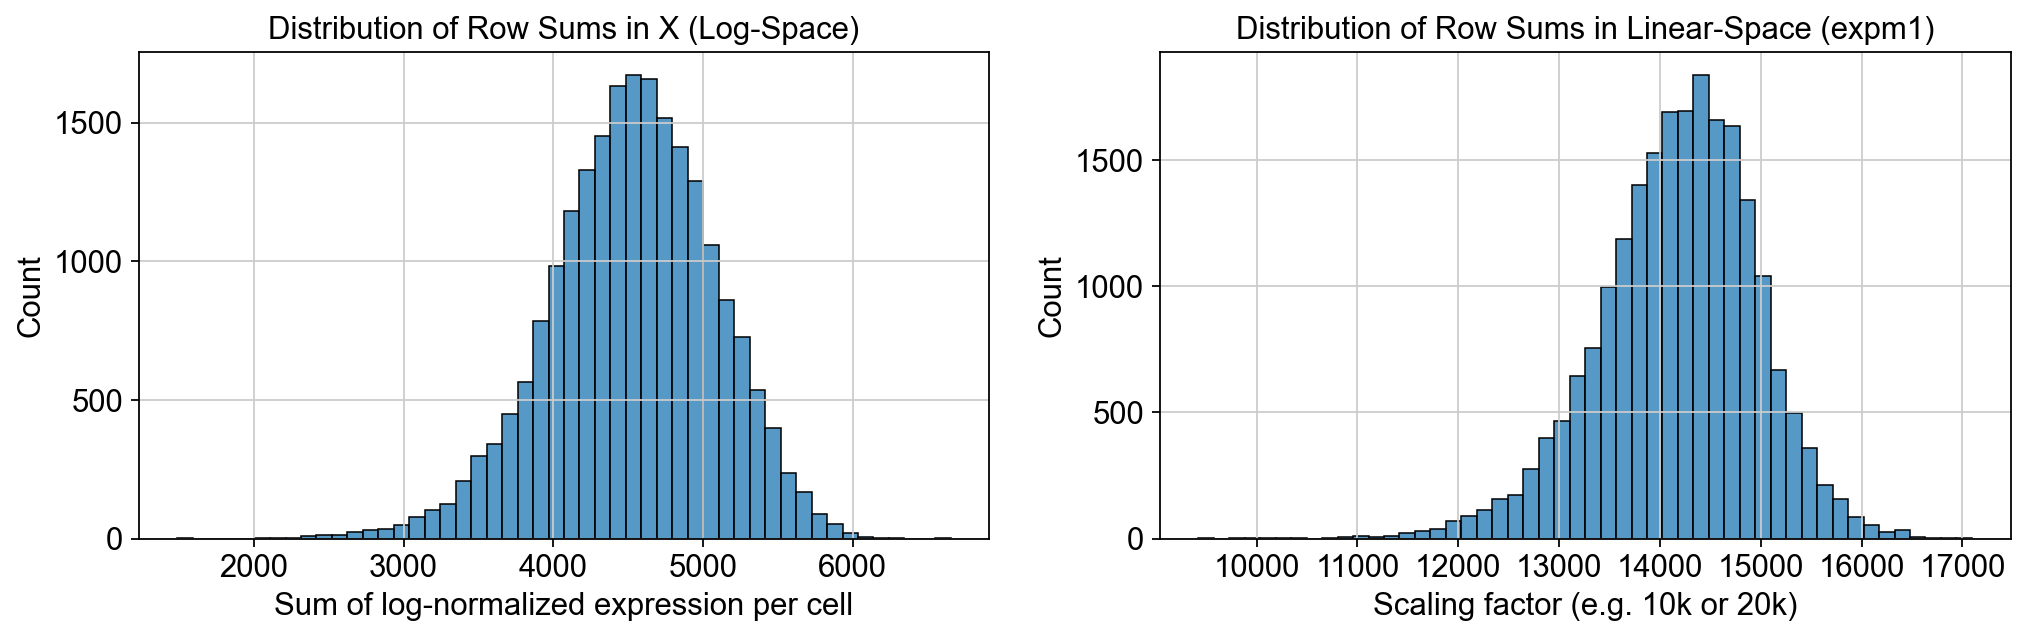


Background Knowledge:
Log-normalization (ln(x+1)) is non-linear and destroys the constant sum property.
Cells with higher sparsity (more non-zero genes) will have higher log-row sums.

The constant scaling (linear row sum) confirms the data is pre-normalized.
Linear Row Sum CV (Coefficient of Variation): 5.52%
A CV of ~5.5% is very low for scRNA-seq, confirming the data was scaled before log-transform.
Minor std (783) is typical due to precision/rounding or minor post-normalization gene filtering.


In [148]:
# Check value range and type
print(f"Max value in X: {adata.X.max():.4f}")
print(f"Are values integers? {np.all(adata.X[:100, :] == adata.X[:100, :].astype(int))}")

# 1. Row sums in log-space
log_row_sums = adata.X.sum(axis=1)
print(f"Log row sum mean: {np.mean(log_row_sums):.2f}, std: {np.std(log_row_sums):.2f}")

# 2. Row sums in linear-space (undoing the log-transform)
linear_row_sums = np.expm1(adata.X).sum(axis=1)
print(f"Linear row sum mean: {np.mean(linear_row_sums):.2f}, std: {np.std(linear_row_sums):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(log_row_sums, bins=50, ax=ax[0])
ax[0].set_title('Distribution of Row Sums in X (Log-Space)')
ax[0].set_xlabel('Sum of log-normalized expression per cell')

sns.histplot(linear_row_sums, bins=50, ax=ax[1])
ax[1].set_title('Distribution of Row Sums in Linear-Space (expm1)')
ax[1].set_xlabel('Scaling factor (e.g. 10k or 20k)')
plt.show()

print("\nBackground Knowledge:")
print("Log-normalization (ln(x+1)) is non-linear and destroys the constant sum property.")
print("Cells with higher sparsity (more non-zero genes) will have higher log-row sums.")
print("\nThe constant scaling (linear row sum) confirms the data is pre-normalized.")
print(f"Linear Row Sum CV (Coefficient of Variation): {np.std(linear_row_sums)/np.mean(linear_row_sums):.2%}")
print("A CV of ~5.5% is very low for scRNA-seq, confirming the data was scaled before log-transform.")
print("Minor std (783) is typical due to precision/rounding or minor post-normalization gene filtering.")

## Quality Control

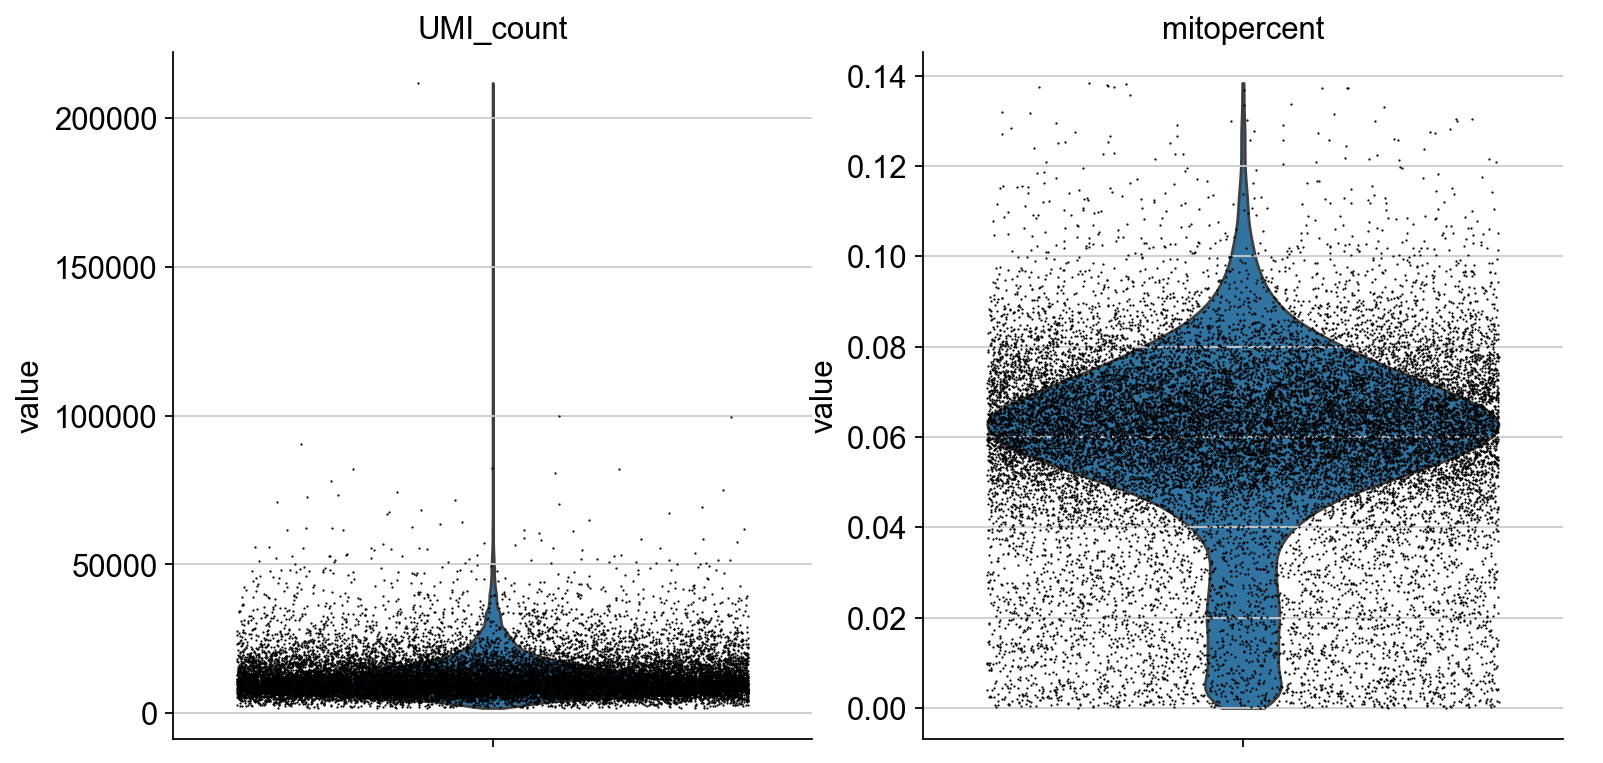

In [149]:
sc.pl.violin(adata, ['UMI_count', 'mitopercent'], jitter=0.4, multi_panel=True)

## Perturbation-Specific Distributions
Analyze the distribution of expression and QC metrics for individual perturbation groups to verify knockdown efficiency and identify group-specific effects.

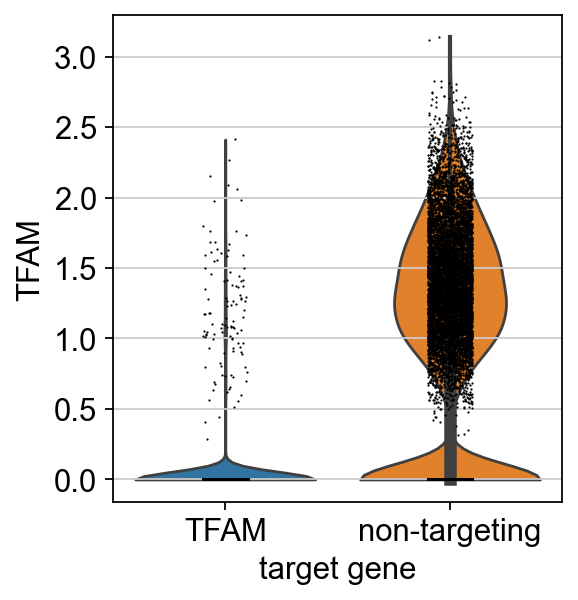

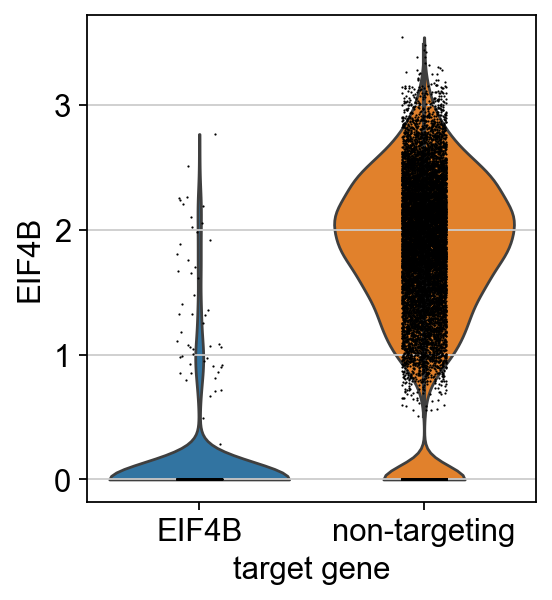

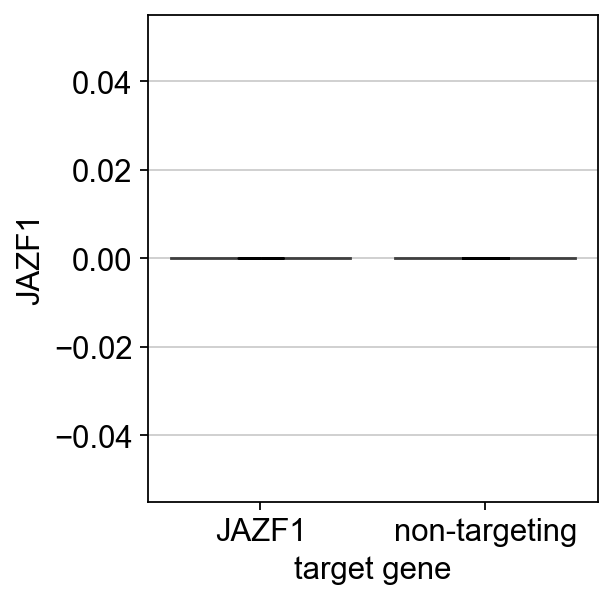

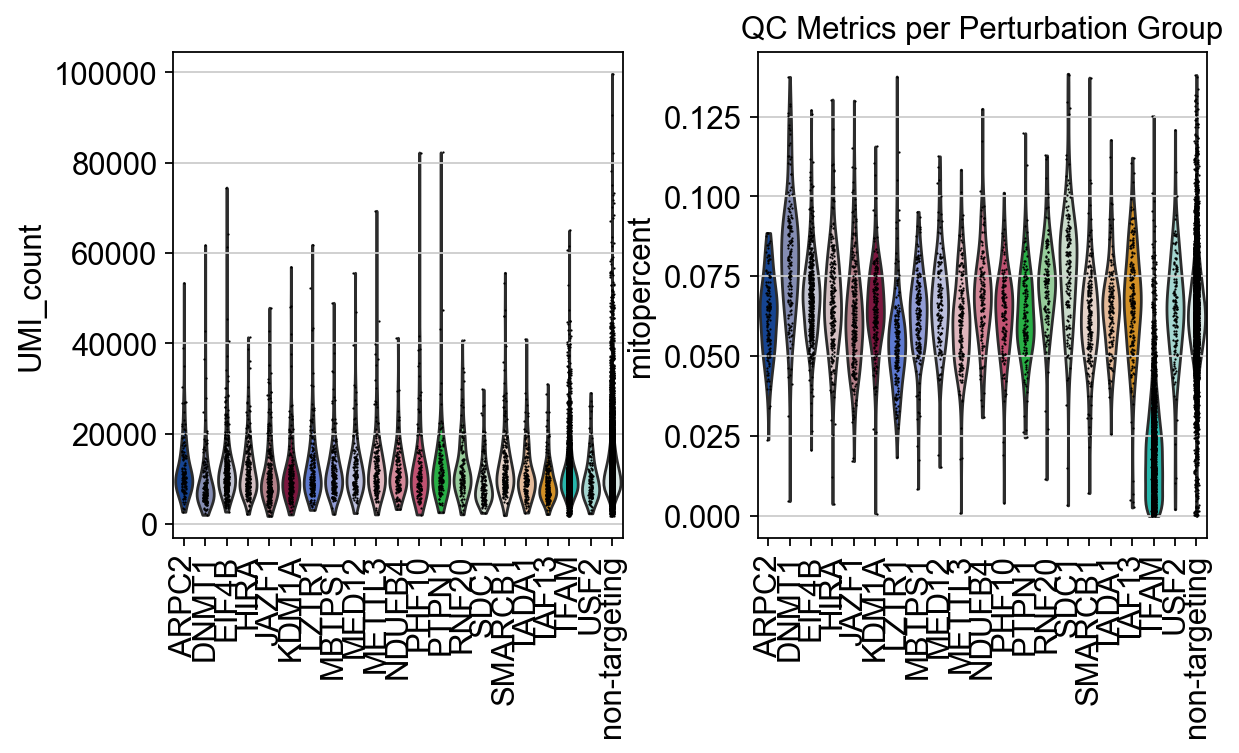


Group-level Statistics (first 10):
     target_gene   mean_expr   max_expr  sparsity
0  non-targeting  0.25204295   8.333305  0.817551
1           TFAM   0.2529789  6.3708496  0.823087
2          EIF4B  0.24504441   6.375639  0.823200
3          JAZF1  0.24378334  6.3788257  0.830268
4           HIRA  0.24685961  6.4435434  0.823068
5        SMARCB1   0.2514393   6.299564  0.814661
6          TAF13  0.24479534  6.2110653  0.840334
7          KDM1A  0.24361141  6.2217016  0.829371
8         MBTPS1   0.2454983  6.1512055  0.824151
9          LZTR1  0.25274807   6.424359  0.819014


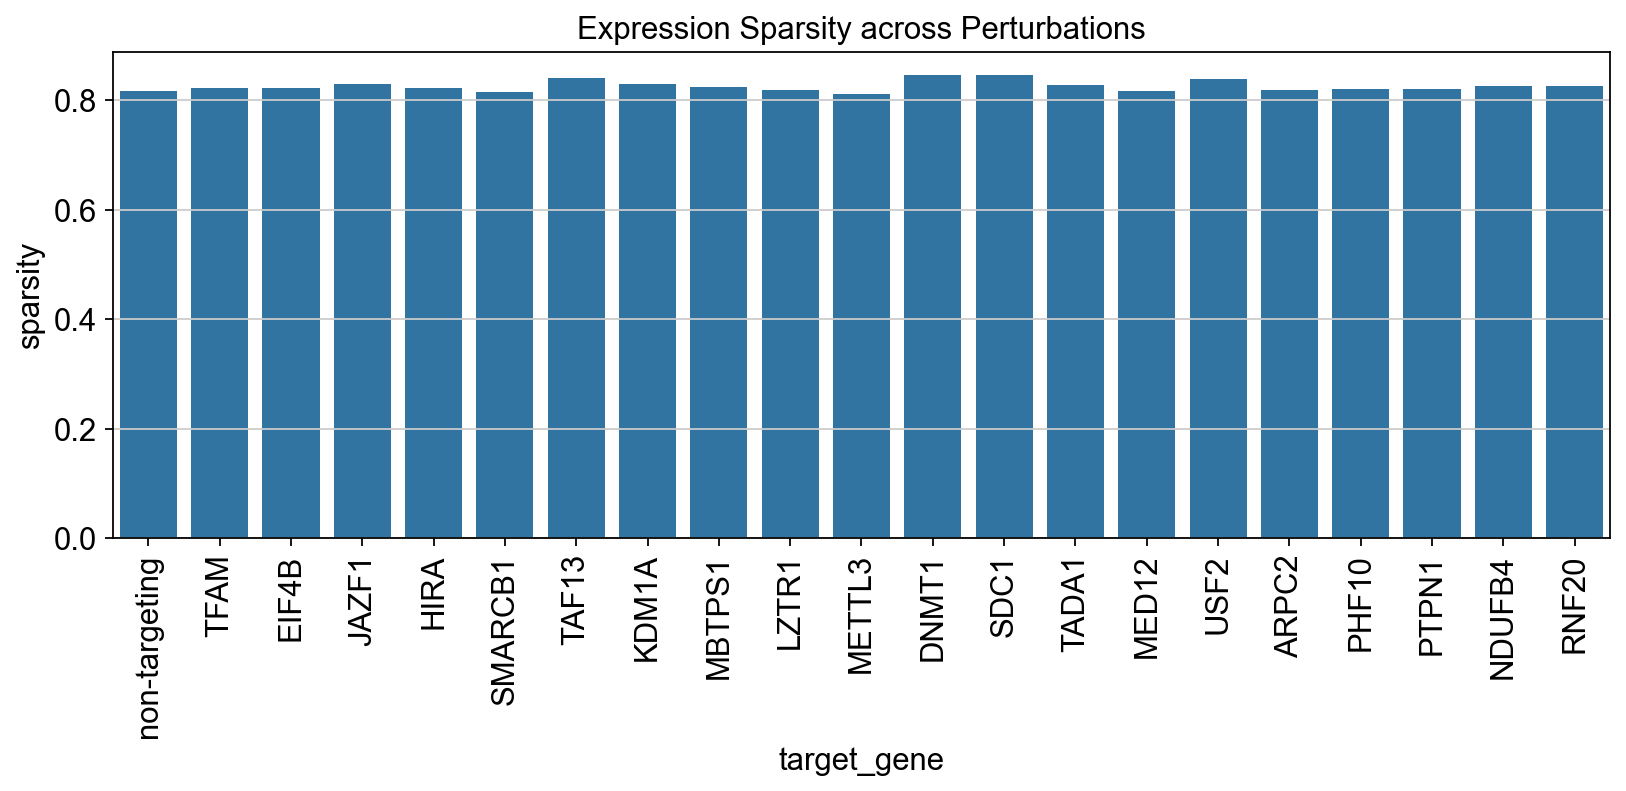

In [150]:
# Re-calculate top targets to ensure independence
counts = adata.obs['target_gene'].value_counts()
top_20 = counts[counts.index != 'non-targeting'].head(20).index.tolist()

# 1. Knockdown Efficiency Check
# Visualize expression of the top 3 targeted genes in their respective groups vs Control
for gene in top_20[:3]:
    if gene in adata.var_names:
        # Create a temporary subset for plotting to avoid unused category issues
        subset = adata[adata.obs['target_gene'].isin(['non-targeting', gene])].copy()
        subset.obs['target_gene'] = subset.obs['target_gene'].cat.remove_unused_categories()
        sc.pl.violin(subset, keys=gene, groupby='target_gene', 
                     inner='boxplot')
    else:
        print(f"Target gene {gene} not found in var_names.")

# 2. Global QC Metrics per Perturbation
# Subsetting to top 20 + control for global comparison
top_groups = ['non-targeting'] + top_20
adata_subset = adata[adata.obs['target_gene'].isin(top_groups)].copy()
adata_subset.obs['target_gene'] = adata_subset.obs['target_gene'].cat.remove_unused_categories()

sc.pl.violin(adata_subset, keys=['UMI_count', 'mitopercent'], 
             groupby='target_gene', rotation=90, show=False)
plt.title('QC Metrics per Perturbation Group')
plt.show()

# 3. Summary Statistics for X per group
group_stats = []
for group in top_groups:
    group_adata = adata[adata.obs['target_gene'] == group]
    if group_adata.n_obs > 0:
        # Use memory-efficient statistics
        X_data = group_adata.X
        nnz = np.count_nonzero(X_data)
        group_stats.append({
            'target_gene': group,
            'mean_expr': X_data.mean(),
            'max_expr': X_data.max(),
            'sparsity': 1.0 - (nnz / X_data.size)
        })

df_stats = pd.DataFrame(group_stats)
print("\nGroup-level Statistics (first 10):")
print(df_stats.head(10))

plt.figure(figsize=(12, 4))
sns.barplot(data=df_stats, x='target_gene', y='sparsity')
plt.title('Expression Sparsity across Perturbations')
plt.xticks(rotation=90)
plt.show()

## Preprocessing
Setting `.raw`. Standard normalization is skipped as the data is already normalized.

In [151]:
# The following steps are skipped because the data is already log-normalized
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)
adata.raw = adata # Store pre-normalized data in .raw before filtering

## Dimensionality Reduction and Clustering

### Highly Variable Gene (HVG) Selection Strategy
We use `n_top_genes=3000` to select the most informative genes. This ranking-based approach is more robust for perturbation studies than hard thresholds, as it ensures a consistent and sufficient number of features (3000) for PCA/UMAP. 

The selection logic follows:
1. **Metric Calculation**: Scanpy calculates the **Mean** (average expression) and **Dispersion** (variation relative to mean) for all genes.
2. **Normalization**: Dispersion is normalized within expression bins to account for the technical correlation between mean expression and variance.
3. **Ranking**: Genes are ranked by their `dispersions_norm` value, and the top 3000 are selected.
4. **Perturbation Safety**: We manually force target genes (knocked-down genes) into the HVG list to ensure that the primary biological signals of interest are retained in downstream analysis.

extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Number of highly variable genes: 3000


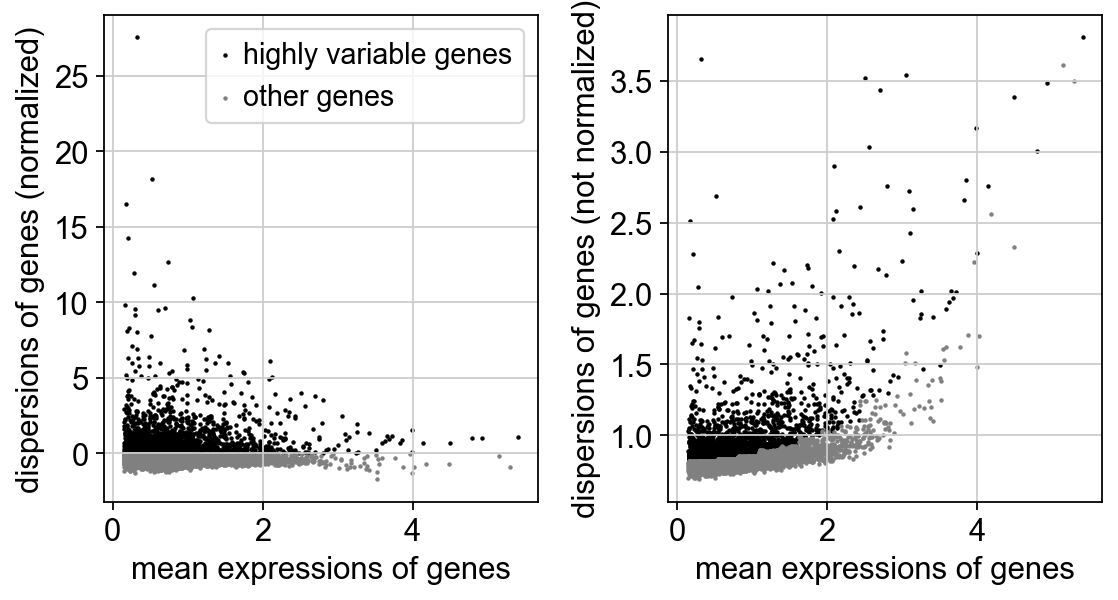

computing PCA
    with n_comps=50
    finished (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


In [152]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor='seurat')
print(f"Number of highly variable genes: {adata.var.highly_variable.sum()}")
sc.pl.highly_variable_genes(adata)

# Ensure target genes are included in the variable list for visualization
target_genes_set = set(adata.obs['target_gene'].unique())
genes_to_keep = [g for g in target_genes_set if g in adata.var_names]
adata.var.loc[genes_to_keep, 'highly_variable'] = True

adata_filtered = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata_filtered, max_value=10)
sc.tl.pca(adata_filtered, svd_solver='arpack')
sc.pp.neighbors(adata_filtered, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_filtered)

# Transfer UMAP back to main object if needed, or work with filtered
adata.obsm['X_umap'] = adata_filtered.obsm['X_umap']

In [153]:
# Save the preprocessed AnnData object for use in the perturbation analysis notebook
adata.write('processed_adata.h5ad')
print("Processed data saved to zyt/processed_adata.h5ad")

Processed data saved to zyt/processed_adata.h5ad


In [154]:
import h5py

def print_h5_tree(path, group=None, prefix=""):
    if group is None:
        with h5py.File(path, 'r') as f:
            print(f"📦 {path}")
            print_h5_tree(path, group=f, prefix="")
        return

    items = list(group.items())
    for i, (name, item) in enumerate(items):
        is_last = (i == len(items) - 1)
        connector = "└── " if is_last else "├── "
        
        if isinstance(item, h5py.Group):
            print(f"{prefix}{connector}📂 {name}/")
            new_prefix = prefix + ("    " if is_last else "│   ")
            print_h5_tree(path, group=item, prefix=new_prefix)
        else:
            info = f"(shape={item.shape}, dtype={item.dtype})"
            print(f"{prefix}{connector}📄 {name:20} {info}")

print_h5_tree('processed_adata.h5ad')


📦 processed_adata.h5ad
├── 📄 X                    (shape=(21412, 18080), dtype=float32)
├── 📂 layers/
├── 📂 obs/
│   ├── 📄 UMI_count            (shape=(21412,), dtype=float32)
│   ├── 📄 _index               (shape=(21412,), dtype=object)
│   ├── 📂 batch_var/
│   │   ├── 📄 categories           (shape=(55,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📄 cell_barcode         (shape=(21412,), dtype=object)
│   ├── 📂 cell_type/
│   │   ├── 📄 categories           (shape=(1,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📄 gem_group            (shape=(21412,), dtype=int64)
│   ├── 📂 gene/
│   │   ├── 📄 categories           (shape=(69,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📂 gene_id/
│   │   ├── 📄 categories           (shape=(69,), dtype=object)
│   │   └── 📄 codes                (shape=(21412,), dtype=int8)
│   ├── 📂 gene_transcript/
│   │   ├── 📄 categories    

In [2]:
import scanpy as sc
adata = sc.read_h5ad('processed_adata.h5ad')

# Check the shape of the full data
print(f"Full data shape: {adata.shape}") 

# Check how many genes are marked as highly variable
hvg_count = adata.var['highly_variable'].sum()
print(f"Number of HVGs: {hvg_count}")

Full data shape: (21412, 18080)
Number of HVGs: 3051
